In [50]:
import gymnasium as gym
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import matplotlib.pyplot as plt
import imageio
import os
from Helper import save_checkpoint_generic, load_checkpoint_generic
from Helper import plot_rewards, create_eval_gifs

# set random seed for reproducibility
manualSeed = 999
random.seed(manualSeed)
torch.manual_seed(manualSeed)
np.random.seed(manualSeed)

print("Gym version:", gym.__version__)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Gym version: 1.2.2
Torch version: 2.9.0+cu126
CUDA available: True


In [51]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states),
            np.array(actions),
            np.array(rewards, dtype=np.float32),
            np.array(next_states),
            np.array(dones, dtype=np.float32)
        )

    def __len__(self):
        return len(self.buffer)


In [52]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, n_hidden=128):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, n_hidden)
        self.fc2 = nn.Linear(n_hidden, n_hidden)
        self.out = nn.Linear(n_hidden, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.out(x)


In [53]:
class DQN_Agent:
    def __init__(self, state_dim, action_dim,
                 gamma=0.99, lr=1e-3,
                 epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995,
                 buffer_capacity=100_000, batch_size=64,
                 tau=0.001,
                 n_hidden=128,
                 device="cpu",
                 network_class=None):

        if isinstance(device, torch.device):
            self.device = device
        else:
            self.device = torch.device(device)

        # Use provided network class or default to QNetwork
        if network_class is None:
            network_class = QNetwork

        # Q-network and target network
        self.policy_net = network_class(state_dim=state_dim, action_dim=action_dim, n_hidden=n_hidden).to(self.device)
        self.target_net = network_class(state_dim=state_dim, action_dim=action_dim, n_hidden=n_hidden).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(buffer_capacity)

        self.gamma = gamma
        self.batch_size = batch_size
        self.action_dim = action_dim

        # epsilon-greedy params
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay

        # soft target update parameter
        self.tau = tau

    def select_action(self, state):
        """Epsilon-greedy: explore randomly or exploit best action."""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)

        # Handle both flat states and image states
        if len(state.shape) == 3:  # Image: (C, H, W)
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)
        else:  # Flat state
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)

        with torch.no_grad():
            q_values = self.policy_net(state_tensor)
        return torch.argmax(q_values, dim=1).item()

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)

        states = torch.tensor(states, dtype=torch.float32).to(self.device)
        actions = torch.tensor(actions, dtype=torch.int64).unsqueeze(1).to(self.device)
        rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1).to(self.device)
        next_states = torch.tensor(next_states, dtype=torch.float32).to(self.device)
        dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1).to(self.device)

        # current Q values
        q_values = self.policy_net(states).gather(1, actions)

        # DQN target: max Q-value from target network
        with torch.no_grad():
            next_q_values = self.target_net(next_states).max(dim=1, keepdim=True)[0]
            target_q = rewards + (1 - dones) * self.gamma * next_q_values

        loss = nn.MSELoss()(q_values, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 10.0)
        self.optimizer.step()

        # decay epsilon
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

        # soft update of target network
        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(self.tau * policy_param.data + (1 - self.tau) * target_param.data)

        return loss.item()


In [54]:
class DDQNAgent:
    def __init__(self, state_dim, action_dim,
                 gamma=0.99, lr=1e-3,
                 epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995,
                 buffer_capacity=100_000, batch_size=64,
                 tau=0.001,
                 n_hidden=128,
                 device="cpu",
                 network_class=None):

        if isinstance(device, torch.device):
            self.device = device
        else:
            self.device = torch.device(device)

        # Use provided network class or default to QNetwork
        if network_class is None:
            network_class = QNetwork

        # policy and target networks
        self.policy_net = network_class(state_dim=state_dim, action_dim=action_dim, n_hidden=n_hidden).to(self.device)
        self.target_net = network_class(state_dim=state_dim, action_dim=action_dim, n_hidden=n_hidden).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(buffer_capacity)

        self.gamma = gamma
        self.batch_size = batch_size
        self.action_dim = action_dim

        # epsilon-greedy params
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay

        # soft target update parameter
        self.tau = tau

    def select_action(self, state):
        """Epsilon-greedy: explore randomly or exploit best action."""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)

        # Handle both flat states and image states
        if len(state.shape) == 3:  # Image: (C, H, W)
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)
        else:  # Flat state
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)

        with torch.no_grad():
            q_values = self.policy_net(state_tensor)
        return torch.argmax(q_values, dim=1).item()

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)

        states = torch.tensor(states, dtype=torch.float32).to(self.device)
        actions = torch.tensor(actions, dtype=torch.int64).unsqueeze(1).to(self.device)
        rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1).to(self.device)
        next_states = torch.tensor(next_states, dtype=torch.float32).to(self.device)
        dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1).to(self.device)

        q_values = self.policy_net(states).gather(1, actions)

        # Double DQN: select action with policy_net, evaluate with target_net
        with torch.no_grad():
            next_actions = self.policy_net(next_states).argmax(dim=1, keepdim=True)
            next_q_values = self.target_net(next_states).gather(1, next_actions)
            target_q = rewards + (1 - dones) * self.gamma * next_q_values

        loss = nn.MSELoss()(q_values, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 10.0)
        self.optimizer.step()

        # decay epsilon
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

        # soft update of target network
        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(self.tau * policy_param.data + (1 - self.tau) * target_param.data)

        return loss.item()


In [25]:
def run_agent_on_env(agent_cls, base_config, env_name, solved_threshold=None):
    env = gym.make(env_name)
    obs_space = env.observation_space
    act_space = env.action_space

    # infer state and action dimensions
    if hasattr(obs_space, 'shape') and obs_space.shape:
        state_dim = int(np.prod(obs_space.shape))
    else:
        raise RuntimeError(f'Unsupported observation space for {env_name}')
    if hasattr(act_space, 'n'):
        action_dim = act_space.n
    else:
        raise RuntimeError(f'Unsupported action space for {env_name}')

    # setup output directories: env_name/agent_type/...
    agent_type = agent_cls.__name__
    config = dict(base_config)
    config['output_dir'] = os.path.join(env_name, agent_type)
    config['checkpoint_dir'] = os.path.join(config['output_dir'], 'checkpoints')
    config['plots_dir'] = os.path.join(config['output_dir'], 'plots')
    config['gifs_dir'] = os.path.join(config['output_dir'], 'gifs')
    os.makedirs(config['checkpoint_dir'], exist_ok=True)
    os.makedirs(config['plots_dir'], exist_ok=True)
    os.makedirs(config['gifs_dir'], exist_ok=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # create agent
    agent = agent_cls(
        state_dim=state_dim,
        action_dim=action_dim,
        gamma=config.get('gamma', 0.99),
        lr=config.get('learning_rate', 1e-3),
        buffer_capacity=config.get('mem_size', 100_000),
        batch_size=config.get('batch_size', 64),
        n_hidden=config.get('n_hidden', 128),
        tau=config.get('tau', 0.001),
        device=device
    )

    # load checkpoint if exists
    ckpt = load_checkpoint_generic(config['checkpoint_dir'], device=device)
    start_episode = 0
    reward_history = []
    if ckpt:
        if 'policy_net' in ckpt:
            agent.policy_net.load_state_dict(ckpt['policy_net'])
        if 'target_net' in ckpt:
            agent.target_net.load_state_dict(ckpt['target_net'])
        if 'optimizer' in ckpt:
            try:
                agent.optimizer.load_state_dict(ckpt['optimizer'])
            except Exception:
                print('Could not restore optimizer state')
        start_episode = ckpt.get('epoch', 0)
        reward_history = ckpt.get('reward_history', [])
        agent.epsilon = ckpt.get('epsilon', agent.epsilon)

    # training loop
    num_episodes = config.get('num_episodes', 5000)
    max_steps = config.get('max_steps_per_episode', 1000)
    checkpoint_freq = config.get('checkpoint_freq', 100)
    learn_step = config.get('learn_step', 1)  # train every N steps

    print(f"\nStarting {agent_type} on {env_name} from episode {start_episode} (device={agent.device})")

    step_count = 0
    for episode in range(start_episode, num_episodes):
        state, _ = env.reset()
        state = np.array(state).reshape(-1)
        total_reward = 0.0

        for t in range(max_steps):
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            next_state = np.array(next_state).reshape(-1)

            # always store experience
            agent.memory.push(state, action, reward, next_state, done)

            # only train every learn_step steps
            step_count += 1
            if step_count % learn_step == 0:
                _ = agent.train_step()

            state = next_state
            total_reward += reward
            if done:
                break

        reward_history.append(total_reward)

        last_x = reward_history[-100:]
        avg_last = float(np.mean(last_x)) if last_x else 0.0
        print(
            f"[{env_name}][{agent_type}] Episode {episode + 1}/{num_episodes} | Reward: {total_reward:.2f} | Last Avg: {avg_last:.2f}")

        # save checkpoint periodically
        if (episode + 1) % checkpoint_freq == 0 or (episode + 1) == num_episodes:
            save_checkpoint_generic(config['checkpoint_dir'], episode + 1, {
                'policy_net': agent.policy_net.state_dict(),
                'target_net': agent.target_net.state_dict(),
                'optimizer': agent.optimizer.state_dict(),
                'epoch': episode + 1,
                'reward_history': reward_history,
                'epsilon': agent.epsilon,
                'config': config
            })

        # early stopping if solved
        if solved_threshold is not None and len(reward_history) >= 100:
            last_avg = np.mean(reward_history[-100:])
            if last_avg >= solved_threshold:
                print(f"✅ Solved {env_name} in episode {episode + 1} with last_avg={last_avg:.2f}")
                save_checkpoint_generic(config['checkpoint_dir'], episode + 1, {
                    'policy_net': agent.policy_net.state_dict(),
                    'target_net': agent.target_net.state_dict(),
                    'optimizer': agent.optimizer.state_dict(),
                    'epoch': episode + 1,
                    'reward_history': reward_history,
                    'epsilon': agent.epsilon,
                    'config': config
                })
                break

    env.close()

    # generate plot
    plot_rewards(reward_history,
                 save_path=os.path.join(config['plots_dir'], f'{agent_type}_{env_name}_training_rewards.png'),
                 show=True,
                 title=f'{agent_type} on {env_name}')

    # generate evaluation GIFs
    create_eval_gifs(agent,
                     out_dir=config['gifs_dir'],
                     env_name=env_name,
                     num_rollouts=5,
                     max_steps_per_rollout=min(500, max_steps),
                     fps=30,
                     eval_epsilon=0.01,
                     render_mode='rgb_array')

    print(f"✅ {agent_type} on {env_name} complete. Saved to {config['output_dir']}\n")
    return reward_history


In [7]:
# Base configurations for DQN and DDQN
agent_config = {
    'batch_size': 128,
    'max_steps_per_episode': 1000,
    'learning_rate': 1e-3,
    'gamma': 0.99,
    'mem_size': 10_000,
    'n_hidden': 128,
    'num_episodes': 5000,
    'checkpoint_freq': 100,
    'tau': 0.001,
    'learn_step': 5
}


🚀 No checkpoint found, starting from scratch

Starting DQN_Agent on LunarLander-v3 from episode 0 (device=cuda)
[LunarLander-v3][DQN_Agent] Episode 1/5000 | Reward: -364.78 | Last Avg: -364.78
[LunarLander-v3][DQN_Agent] Episode 2/5000 | Reward: -181.41 | Last Avg: -273.10
[LunarLander-v3][DQN_Agent] Episode 3/5000 | Reward: -513.47 | Last Avg: -353.22
[LunarLander-v3][DQN_Agent] Episode 4/5000 | Reward: -444.02 | Last Avg: -375.92
[LunarLander-v3][DQN_Agent] Episode 5/5000 | Reward: -88.25 | Last Avg: -318.39
[LunarLander-v3][DQN_Agent] Episode 6/5000 | Reward: -342.73 | Last Avg: -322.44
[LunarLander-v3][DQN_Agent] Episode 7/5000 | Reward: -365.65 | Last Avg: -328.62
[LunarLander-v3][DQN_Agent] Episode 8/5000 | Reward: -113.07 | Last Avg: -301.67
[LunarLander-v3][DQN_Agent] Episode 9/5000 | Reward: -138.39 | Last Avg: -283.53
[LunarLander-v3][DQN_Agent] Episode 10/5000 | Reward: -83.27 | Last Avg: -263.50
[LunarLander-v3][DQN_Agent] Episode 11/5000 | Reward: -109.66 | Last Avg: -249.

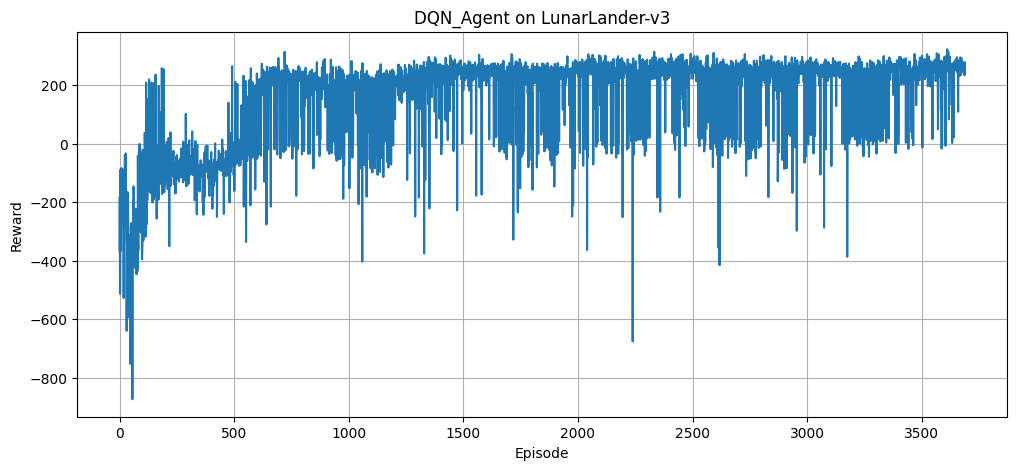

Saved: LunarLander-v3\DQN_Agent\gifs\LunarLander-v3_rollout_1.gif
Saved: LunarLander-v3\DQN_Agent\gifs\LunarLander-v3_rollout_2.gif
Saved: LunarLander-v3\DQN_Agent\gifs\LunarLander-v3_rollout_3.gif
Saved: LunarLander-v3\DQN_Agent\gifs\LunarLander-v3_rollout_4.gif
Saved: LunarLander-v3\DQN_Agent\gifs\LunarLander-v3_rollout_5.gif
Saved combined gif: LunarLander-v3\DQN_Agent\gifs\LunarLander-v3_combined.gif
✅ DQN_Agent on LunarLander-v3 complete. Saved to LunarLander-v3\DQN_Agent

🚀 No checkpoint found, starting from scratch

Starting DDQNAgent on LunarLander-v3 from episode 0 (device=cuda)
[LunarLander-v3][DDQNAgent] Episode 1/5000 | Reward: -31.62 | Last Avg: -31.62
[LunarLander-v3][DDQNAgent] Episode 2/5000 | Reward: -127.91 | Last Avg: -79.77
[LunarLander-v3][DDQNAgent] Episode 3/5000 | Reward: -387.37 | Last Avg: -182.30
[LunarLander-v3][DDQNAgent] Episode 4/5000 | Reward: -81.98 | Last Avg: -157.22
[LunarLander-v3][DDQNAgent] Episode 5/5000 | Reward: -202.97 | Last Avg: -166.37
[Lun

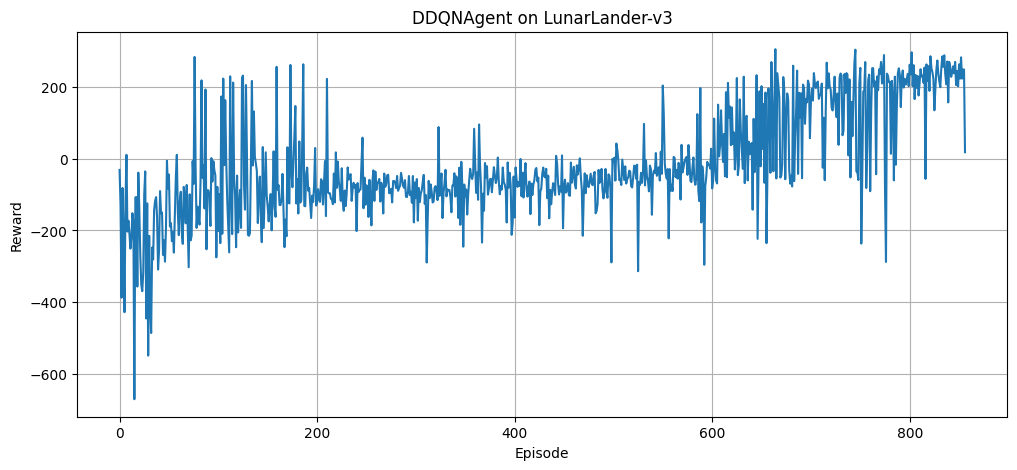

Saved: LunarLander-v3\DDQNAgent\gifs\LunarLander-v3_rollout_1.gif
Saved: LunarLander-v3\DDQNAgent\gifs\LunarLander-v3_rollout_2.gif
Saved: LunarLander-v3\DDQNAgent\gifs\LunarLander-v3_rollout_3.gif
Saved: LunarLander-v3\DDQNAgent\gifs\LunarLander-v3_rollout_4.gif
Saved: LunarLander-v3\DDQNAgent\gifs\LunarLander-v3_rollout_5.gif
Saved combined gif: LunarLander-v3\DDQNAgent\gifs\LunarLander-v3_combined.gif
✅ DDQNAgent on LunarLander-v3 complete. Saved to LunarLander-v3\DDQNAgent



[np.float64(-31.621198681071533),
 np.float64(-127.91375250213989),
 np.float64(-387.37104335860454),
 np.float64(-81.97564030329087),
 np.float64(-202.9712962358866),
 np.float64(-427.80702200967073),
 np.float64(-125.63689313951916),
 np.float64(10.37476712098001),
 np.float64(-203.2995497112783),
 np.float64(-173.06657354413284),
 np.float64(-208.73398198004617),
 np.float64(-250.74061101911693),
 np.float64(-220.20360569202245),
 np.float64(-152.1487762134394),
 np.float64(-176.2870559815778),
 np.float64(-670.0507670046086),
 np.float64(-108.23176429564627),
 np.float64(-107.11614430379979),
 np.float64(-356.3350130485488),
 np.float64(-39.19086583401924),
 np.float64(-140.21539190305685),
 np.float64(-269.59415455964654),
 np.float64(-350.75125723163535),
 np.float64(-369.25457648207714),
 np.float64(-316.5660932717682),
 np.float64(-98.8548764480822),
 np.float64(-35.784837935326294),
 np.float64(-445.1567311255444),
 np.float64(-124.73072407208066),
 np.float64(-548.62383457786

In [17]:
# # Train on LunarLander-v3
# run_agent_on_env(DQN_Agent, agent_config, 'LunarLander-v3', solved_threshold=250)
# run_agent_on_env(DDQNAgent, agent_config, 'LunarLander-v3', solved_threshold=200)


🚀 No checkpoint found, starting from scratch

Starting DQN_Agent on CartPole-v1 from episode 0 (device=cuda)
[CartPole-v1][DQN_Agent] Episode 1/5000 | Reward: 22.00 | Last Avg: 22.00
[CartPole-v1][DQN_Agent] Episode 2/5000 | Reward: 55.00 | Last Avg: 38.50
[CartPole-v1][DQN_Agent] Episode 3/5000 | Reward: 21.00 | Last Avg: 32.67
[CartPole-v1][DQN_Agent] Episode 4/5000 | Reward: 15.00 | Last Avg: 28.25
[CartPole-v1][DQN_Agent] Episode 5/5000 | Reward: 14.00 | Last Avg: 25.40
[CartPole-v1][DQN_Agent] Episode 6/5000 | Reward: 19.00 | Last Avg: 24.33
[CartPole-v1][DQN_Agent] Episode 7/5000 | Reward: 12.00 | Last Avg: 22.57
[CartPole-v1][DQN_Agent] Episode 8/5000 | Reward: 17.00 | Last Avg: 21.88
[CartPole-v1][DQN_Agent] Episode 9/5000 | Reward: 22.00 | Last Avg: 21.89
[CartPole-v1][DQN_Agent] Episode 10/5000 | Reward: 13.00 | Last Avg: 21.00
[CartPole-v1][DQN_Agent] Episode 11/5000 | Reward: 10.00 | Last Avg: 20.00
[CartPole-v1][DQN_Agent] Episode 12/5000 | Reward: 15.00 | Last Avg: 19.58


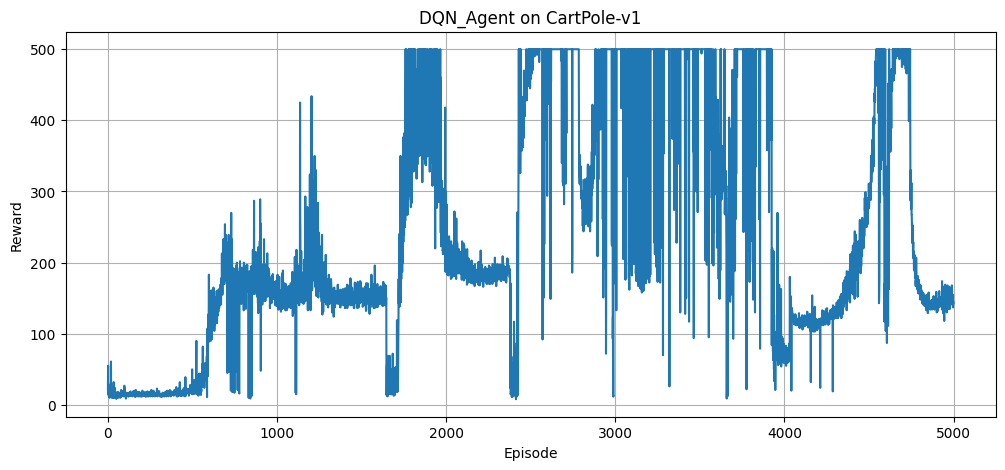

Saved: CartPole-v1\DQN_Agent\gifs\CartPole-v1_rollout_1.gif
Saved: CartPole-v1\DQN_Agent\gifs\CartPole-v1_rollout_2.gif
Saved: CartPole-v1\DQN_Agent\gifs\CartPole-v1_rollout_3.gif
Saved: CartPole-v1\DQN_Agent\gifs\CartPole-v1_rollout_4.gif
Saved: CartPole-v1\DQN_Agent\gifs\CartPole-v1_rollout_5.gif
Saved combined gif: CartPole-v1\DQN_Agent\gifs\CartPole-v1_combined.gif
✅ DQN_Agent on CartPole-v1 complete. Saved to CartPole-v1\DQN_Agent

🚀 No checkpoint found, starting from scratch

Starting DDQNAgent on CartPole-v1 from episode 0 (device=cuda)
[CartPole-v1][DDQNAgent] Episode 1/5000 | Reward: 12.00 | Last Avg: 12.00
[CartPole-v1][DDQNAgent] Episode 2/5000 | Reward: 16.00 | Last Avg: 14.00
[CartPole-v1][DDQNAgent] Episode 3/5000 | Reward: 12.00 | Last Avg: 13.33
[CartPole-v1][DDQNAgent] Episode 4/5000 | Reward: 52.00 | Last Avg: 23.00
[CartPole-v1][DDQNAgent] Episode 5/5000 | Reward: 12.00 | Last Avg: 20.80
[CartPole-v1][DDQNAgent] Episode 6/5000 | Reward: 27.00 | Last Avg: 21.83
[CartP

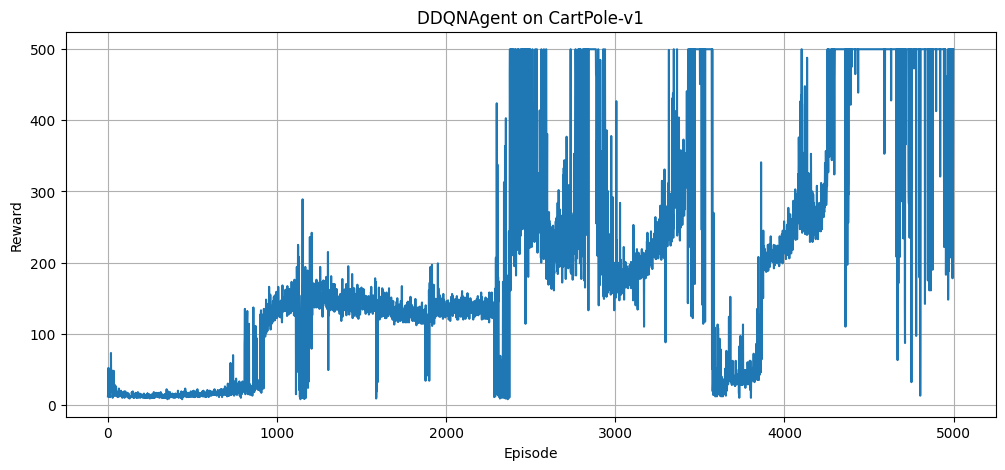

Saved: CartPole-v1\DDQNAgent\gifs\CartPole-v1_rollout_1.gif
Saved: CartPole-v1\DDQNAgent\gifs\CartPole-v1_rollout_2.gif
Saved: CartPole-v1\DDQNAgent\gifs\CartPole-v1_rollout_3.gif
Saved: CartPole-v1\DDQNAgent\gifs\CartPole-v1_rollout_4.gif
Saved: CartPole-v1\DDQNAgent\gifs\CartPole-v1_rollout_5.gif
Saved combined gif: CartPole-v1\DDQNAgent\gifs\CartPole-v1_combined.gif
✅ DDQNAgent on CartPole-v1 complete. Saved to CartPole-v1\DDQNAgent



[12.0,
 16.0,
 12.0,
 52.0,
 12.0,
 27.0,
 18.0,
 24.0,
 11.0,
 34.0,
 34.0,
 20.0,
 18.0,
 11.0,
 45.0,
 37.0,
 29.0,
 33.0,
 73.0,
 34.0,
 47.0,
 49.0,
 21.0,
 18.0,
 28.0,
 22.0,
 20.0,
 28.0,
 10.0,
 14.0,
 30.0,
 23.0,
 16.0,
 22.0,
 48.0,
 26.0,
 22.0,
 25.0,
 25.0,
 21.0,
 13.0,
 28.0,
 16.0,
 13.0,
 15.0,
 14.0,
 14.0,
 15.0,
 26.0,
 14.0,
 14.0,
 19.0,
 13.0,
 14.0,
 16.0,
 14.0,
 15.0,
 11.0,
 15.0,
 12.0,
 15.0,
 15.0,
 19.0,
 12.0,
 14.0,
 23.0,
 15.0,
 17.0,
 14.0,
 14.0,
 12.0,
 15.0,
 16.0,
 13.0,
 13.0,
 13.0,
 18.0,
 20.0,
 14.0,
 15.0,
 14.0,
 13.0,
 15.0,
 16.0,
 17.0,
 10.0,
 15.0,
 12.0,
 18.0,
 14.0,
 14.0,
 15.0,
 12.0,
 14.0,
 16.0,
 13.0,
 19.0,
 17.0,
 10.0,
 15.0,
 12.0,
 13.0,
 12.0,
 19.0,
 13.0,
 12.0,
 13.0,
 12.0,
 16.0,
 12.0,
 15.0,
 13.0,
 15.0,
 15.0,
 14.0,
 17.0,
 16.0,
 14.0,
 12.0,
 11.0,
 16.0,
 10.0,
 12.0,
 13.0,
 15.0,
 10.0,
 13.0,
 13.0,
 9.0,
 11.0,
 12.0,
 12.0,
 12.0,
 12.0,
 11.0,
 12.0,
 12.0,
 11.0,
 11.0,
 12.0,
 14.0,
 18.0,
 16.0,


In [18]:
# # Train on CartPole-v1
# run_agent_on_env(DQN_Agent, agent_config, 'CartPole-v1', solved_threshold=None)
# run_agent_on_env(DDQNAgent, agent_config, 'CartPole-v1', solved_threshold=None)


🚀 No checkpoint found, starting from scratch

Starting DQN_Agent on Acrobot-v1 from episode 0 (device=cuda)
[Acrobot-v1][DQN_Agent] Episode 1/5000 | Reward: -500.00 | Last Avg: -500.00
[Acrobot-v1][DQN_Agent] Episode 2/5000 | Reward: -488.00 | Last Avg: -494.00
[Acrobot-v1][DQN_Agent] Episode 3/5000 | Reward: -256.00 | Last Avg: -414.67
[Acrobot-v1][DQN_Agent] Episode 4/5000 | Reward: -215.00 | Last Avg: -364.75
[Acrobot-v1][DQN_Agent] Episode 5/5000 | Reward: -169.00 | Last Avg: -325.60
[Acrobot-v1][DQN_Agent] Episode 6/5000 | Reward: -169.00 | Last Avg: -299.50
[Acrobot-v1][DQN_Agent] Episode 7/5000 | Reward: -206.00 | Last Avg: -286.14
[Acrobot-v1][DQN_Agent] Episode 8/5000 | Reward: -238.00 | Last Avg: -280.12
[Acrobot-v1][DQN_Agent] Episode 9/5000 | Reward: -500.00 | Last Avg: -304.56
[Acrobot-v1][DQN_Agent] Episode 10/5000 | Reward: -373.00 | Last Avg: -311.40
[Acrobot-v1][DQN_Agent] Episode 11/5000 | Reward: -257.00 | Last Avg: -306.45
[Acrobot-v1][DQN_Agent] Episode 12/5000 | R

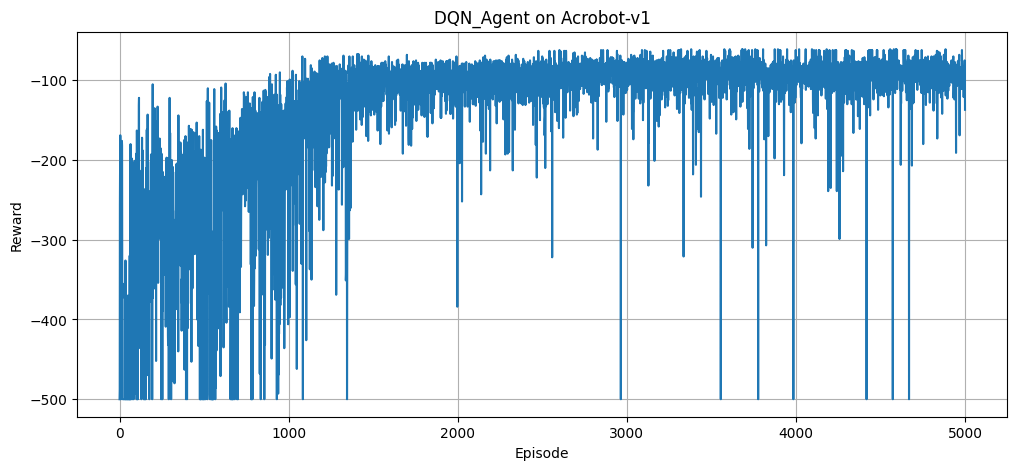

Saved: Acrobot-v1\DQN_Agent\gifs\Acrobot-v1_rollout_1.gif
Saved: Acrobot-v1\DQN_Agent\gifs\Acrobot-v1_rollout_2.gif
Saved: Acrobot-v1\DQN_Agent\gifs\Acrobot-v1_rollout_3.gif
Saved: Acrobot-v1\DQN_Agent\gifs\Acrobot-v1_rollout_4.gif
Saved: Acrobot-v1\DQN_Agent\gifs\Acrobot-v1_rollout_5.gif
Saved combined gif: Acrobot-v1\DQN_Agent\gifs\Acrobot-v1_combined.gif
✅ DQN_Agent on Acrobot-v1 complete. Saved to Acrobot-v1\DQN_Agent

🚀 No checkpoint found, starting from scratch

Starting DDQNAgent on Acrobot-v1 from episode 0 (device=cuda)
[Acrobot-v1][DDQNAgent] Episode 1/5000 | Reward: -500.00 | Last Avg: -500.00
[Acrobot-v1][DDQNAgent] Episode 2/5000 | Reward: -373.00 | Last Avg: -436.50
[Acrobot-v1][DDQNAgent] Episode 3/5000 | Reward: -500.00 | Last Avg: -457.67
[Acrobot-v1][DDQNAgent] Episode 4/5000 | Reward: -500.00 | Last Avg: -468.25
[Acrobot-v1][DDQNAgent] Episode 5/5000 | Reward: -500.00 | Last Avg: -474.60
[Acrobot-v1][DDQNAgent] Episode 6/5000 | Reward: -500.00 | Last Avg: -478.83
[Ac

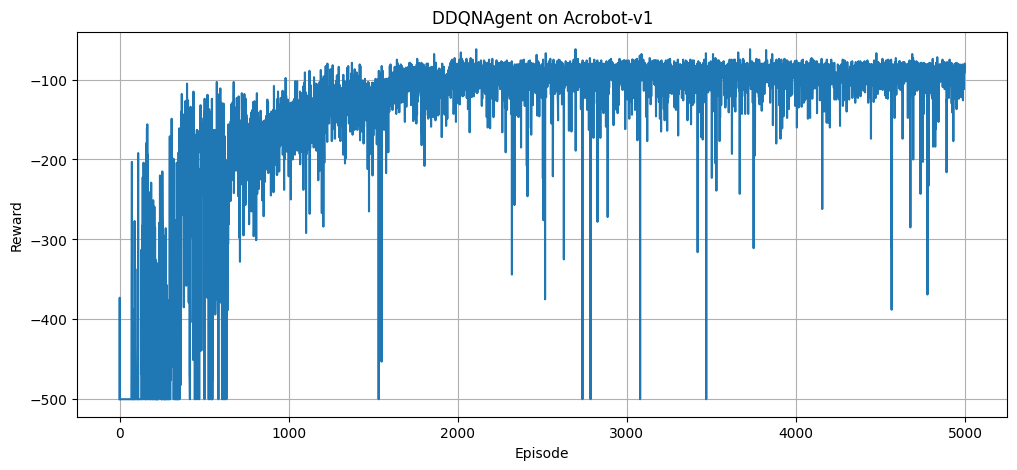

Saved: Acrobot-v1\DDQNAgent\gifs\Acrobot-v1_rollout_1.gif
Saved: Acrobot-v1\DDQNAgent\gifs\Acrobot-v1_rollout_2.gif
Saved: Acrobot-v1\DDQNAgent\gifs\Acrobot-v1_rollout_3.gif
Saved: Acrobot-v1\DDQNAgent\gifs\Acrobot-v1_rollout_4.gif
Saved: Acrobot-v1\DDQNAgent\gifs\Acrobot-v1_rollout_5.gif
Saved combined gif: Acrobot-v1\DDQNAgent\gifs\Acrobot-v1_combined.gif
✅ DDQNAgent on Acrobot-v1 complete. Saved to Acrobot-v1\DDQNAgent



[-500.0,
 -373.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -403.0,
 -339.0,
 -203.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -421.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -486.0,
 -500.0,
 -387.0,
 -500.0,
 -434.0,
 -277.0,
 -366.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -500.0,
 -337.0,
 -500.0,
 -430.0,
 -192.0,
 

In [19]:
# # Train on Acrobot-v1
# run_agent_on_env(DQN_Agent, agent_config, 'Acrobot-v1', solved_threshold=None)
# run_agent_on_env(DDQNAgent, agent_config, 'Acrobot-v1', solved_threshold=None)


In [26]:
class QNetwork_CNN(nn.Module):
    def __init__(self, action_dim, state_dim=None, n_hidden=None):
        """CNN Q-Network for Atari-style observations.
        state_dim and n_hidden are ignored but kept for compatibility.
        """
        super().__init__()
        # Conv layers: expect (batch, 4, 84, 84) input
        self.conv1 = nn.Conv2d(4, 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)

        # FC layers: 64*7*7 = 3136 inputs
        self.fc1 = nn.Linear(3136, 512)
        self.fc2 = nn.Linear(512, action_dim)

    def forward(self, x):
        # Normalize to [0, 1] if input is uint8 [0, 255]
        if x.dtype == torch.uint8:
            x = x.float() / 255.0
        elif x.max() > 1.0:
            x = x / 255.0

        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        return self.fc2(x)


In [27]:
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation
import ale_py

gym.register_envs(ale_py)


def make_pong_env():
    """Create Pong environment with AtariPreprocessing and FrameStack."""
    env = gym.make("ALE/Pong-v5", frameskip=1)
    env = AtariPreprocessing(
        env,
        grayscale_obs=True,
        scale_obs=False,  # keeps uint8 [0, 255], normalize in CNN
        frame_skip=4,
        screen_size=84
    )
    env = FrameStackObservation(env, 4)  # Stack 4 frames to capture motion
    return env


In [43]:
def create_pong_game_gifs(agent, output_dir,
                          min_score=None, max_score=None,
                          num_games=5, max_attempts=20):
    os.makedirs(output_dir, exist_ok=True)
    agent.policy_net.eval()

    games_recorded = 0
    attempts = 0

    print(f"\n🎬 Recording Pong games...")
    if min_score:
        print(f"   Target: Games with score >= {min_score}")
    if max_score:
        print(f"   Target: Games with score <= {max_score}")

    while games_recorded < num_games and attempts < max_attempts:
        attempts += 1
        frames = []

        # Create environments
        eval_env = make_pong_env()
        render_env = gym.make("ALE/Pong-v5", render_mode='rgb_array')

        state, _ = eval_env.reset()
        render_env.reset()
        state = np.array(state)

        total_reward = 0.0
        step_count = 0

        # Play until game ends
        while True:
            # Capture frame
            frame = render_env.render()
            if frame is not None:
                frames.append(frame)

            # Select action (very low epsilon for evaluation)
            old_epsilon = agent.epsilon
            agent.epsilon = 0.01
            action = agent.select_action(state)
            agent.epsilon = old_epsilon

            # Step both environments
            next_state, reward, terminated, truncated, info = eval_env.step(action)
            render_env.step(action)
            done = terminated or truncated

            state = np.array(next_state)
            total_reward += reward
            step_count += 1

            if done:
                break

        eval_env.close()
        render_env.close()

        # Check if game meets criteria
        should_save = True
        if min_score is not None and total_reward < min_score:
            should_save = False
        if max_score is not None and total_reward > max_score:
            should_save = False

        if should_save and frames:
            games_recorded += 1

            # Determine game outcome
            if total_reward > 0:
                outcome = "WIN"
            elif total_reward < 0:
                outcome = "LOSS"
            else:
                outcome = "DRAW"

            gif_path = os.path.join(output_dir,
                                    f'game_{games_recorded}_{outcome}_score{int(total_reward)}.gif')
            imageio.mimsave(gif_path, frames, fps=30)
            print(
                f"   ✅ Saved game {games_recorded}/{num_games}: {outcome} (score: {total_reward}, steps: {step_count})")
            print(f"      {gif_path}")
        else:
            print(f"   ⏭️ Attempt {attempts}: Score {total_reward:.0f} (not matching criteria)")

    if games_recorded < num_games:
        print(f"\n⚠️ Only found {games_recorded}/{num_games} games matching criteria after {attempts} attempts")
    else:
        print(f"\n✅ Successfully recorded {games_recorded} games!")

    return games_recorded

In [44]:
def train_pong_agent(agent_cls, config, env_name='ALE/Pong-v5', solved_threshold=None):
    """Train DQN or DDQN agent on Pong with CNN Q-network."""

    # Create environment
    env = make_pong_env()
    action_dim = env.action_space.n

    # Setup output directories
    agent_type = agent_cls.__name__
    output_dir = os.path.join(env_name, agent_type)
    checkpoint_dir = os.path.join(output_dir, 'checkpoints')
    plots_dir = os.path.join(output_dir, 'plots')
    gifs_dir = os.path.join(output_dir, 'gifs')
    os.makedirs(checkpoint_dir, exist_ok=True)
    os.makedirs(plots_dir, exist_ok=True)
    os.makedirs(gifs_dir, exist_ok=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Create agent with CNN network - use dummy epsilon values, we'll manage it manually
    agent = agent_cls(
        state_dim=None,  # Not used by CNN
        action_dim=action_dim,
        gamma=config['gamma'],
        lr=config['learning_rate'],
        epsilon_start=1.0,  # Will be overridden
        epsilon_end=0.01,
        epsilon_decay=1.0,  # Disabled, we'll use linear decay
        buffer_capacity=config['mem_size'],
        batch_size=config['batch_size'],
        tau=config.get('tau', 0.001),
        n_hidden=None,  # Not used by CNN
        device=device,
        network_class=QNetwork_CNN
    )

    # Load checkpoint if exists
    ckpt = load_checkpoint_generic(checkpoint_dir, device=device)
    start_episode = 0
    reward_history = []
    loss_history = []
    global_step = 0

    if ckpt:
        if 'policy_net' in ckpt:
            agent.policy_net.load_state_dict(ckpt['policy_net'])
        if 'target_net' in ckpt:
            agent.target_net.load_state_dict(ckpt['target_net'])
        if 'optimizer' in ckpt:
            try:
                agent.optimizer.load_state_dict(ckpt['optimizer'])
            except Exception:
                print('Could not restore optimizer state')
        start_episode = ckpt.get('epoch', 0)
        reward_history = ckpt.get('reward_history', [])
        loss_history = ckpt.get('loss_history', [])
        global_step = ckpt.get('global_step', 0)

    # Training parameters
    num_episodes = config['num_episodes']
    max_steps = config['max_steps_per_episode']
    checkpoint_freq = config.get('checkpoint_freq', 50)
    target_update_freq = config.get('target_update_freq', 10000)
    learning_starts = config.get('learning_starts', 10000)
    train_freq = config.get('train_freq', 4)

    # Epsilon linear decay parameters
    epsilon_start = config.get('epsilon_start', 1.0)
    epsilon_end = config.get('epsilon_end', 0.01)
    epsilon_decay_steps = config.get('epsilon_decay_steps', 200000)

    print(f"\nStarting {agent_type} on {env_name} from episode {start_episode}")
    print(f"Config: {config}")
    print(f"Epsilon will decay linearly from {epsilon_start} to {epsilon_end} over {epsilon_decay_steps} steps\n")

    for episode in range(start_episode, num_episodes):
        state, _ = env.reset()
        state = np.array(state)  # Convert LazyFrames to numpy array (4, 84, 84)
        total_reward = 0.0
        episode_losses = []

        for t in range(max_steps):
            # Linear epsilon decay
            if global_step < epsilon_decay_steps:
                agent.epsilon = epsilon_start - (epsilon_start - epsilon_end) * (global_step / epsilon_decay_steps)
            else:
                agent.epsilon = epsilon_end

            # Select and perform action
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            next_state = np.array(next_state)

            # Store transition
            agent.memory.push(state, action, reward, next_state, done)

            # Train agent only after learning_starts and every train_freq steps
            if global_step >= learning_starts and global_step % train_freq == 0:
                loss = agent.train_step()
                if loss is not None:
                    episode_losses.append(loss)

            # Hard update target network every N steps (for DDQN requirement)
            global_step += 1
            if global_step % target_update_freq == 0:
                agent.target_net.load_state_dict(agent.policy_net.state_dict())
                print(f"  🎯 Hard update target network at step {global_step}")

            state = next_state
            total_reward += reward

            if done:
                break

        reward_history.append(total_reward)

        avg_loss = np.mean(episode_losses) if episode_losses else 0.0
        loss_history.append(avg_loss)

        # Calculate statistics
        last_100 = reward_history[-100:]
        avg_100 = np.mean(last_100) if last_100 else 0.0

        print(f"[{env_name}][{agent_type}] Episode {episode + 1}/{num_episodes} | "
              f"Reward: {total_reward:.1f} | Avg100: {avg_100:.2f} | "
              f"Loss: {avg_loss:.4f} | Epsilon: {agent.epsilon:.3f} | Steps: {t + 1} | TotalSteps: {global_step}")

        # early stopping if solved
        if solved_threshold is not None and len(reward_history) >= 50:
            last_avg = np.mean(reward_history[-50:])
            if last_avg >= solved_threshold:
                print(f"✅ Solved {env_name} in episode {episode + 1} with last_avg={last_avg:.2f}")
                save_checkpoint_generic(checkpoint_dir, episode + 1, {
                    'policy_net': agent.policy_net.state_dict(),
                    'target_net': agent.target_net.state_dict(),
                    'optimizer': agent.optimizer.state_dict(),
                    'epoch': episode + 1,
                    'reward_history': reward_history,
                    'loss_history': loss_history,
                    'global_step': global_step,
                    'config': config
                })
                break

        # Save checkpoint periodically
        if (episode + 1) % checkpoint_freq == 0 or (episode + 1) == num_episodes:
            save_checkpoint_generic(checkpoint_dir, episode + 1, {
                'policy_net': agent.policy_net.state_dict(),
                'target_net': agent.target_net.state_dict(),
                'optimizer': agent.optimizer.state_dict(),
                'epoch': episode + 1,
                'reward_history': reward_history,
                'loss_history': loss_history,
                'global_step': global_step,
                'config': config
            })

    env.close()

    # Generate reward plot
    plot_rewards(reward_history,
                 save_path=os.path.join(plots_dir, f'{agent_type}_{env_name.replace("/", "_")}_training_rewards.png'),
                 show=True,
                 title=f'{agent_type} on {env_name} - Training Rewards')

    # Generate loss plot
    if loss_history:
        fig = plt.figure(figsize=(12, 5))
        plt.plot(loss_history)
        plt.xlabel('Episode')
        plt.ylabel('Loss')
        plt.title(f'{agent_type} on {env_name} - Training Loss')
        plt.grid(True)
        loss_plot_path = os.path.join(plots_dir, f'{agent_type}_{env_name.replace("/", "_")}_training_loss.png')
        fig.savefig(loss_plot_path)
        print(f'Saved loss plot to: {loss_plot_path}')
        plt.show()

    # Generate evaluation GIFs
    print("\nGenerating evaluation GIFs...")
    eval_env_name = env_name

    # Custom GIF creation for Pong with frame stacking
    #
    # agent.policy_net.eval()
    # combined_frames = []
    #
    # for rollout in range(5):
    #     frames = []
    #     eval_env = make_pong_env()
    #     eval_env_render = gym.make("ALE/Pong-v5", render_mode='rgb_array')
    #
    #     state, _ = eval_env.reset()
    #     eval_env_render.reset()
    #     state = np.array(state)
    #
    #     for step in range(500):
    #         # Get frame for GIF
    #         frame = eval_env_render.render()
    #         if frame is not None:
    #             frames.append(frame)
    #             combined_frames.append(frame)
    #
    #         # Select action with low epsilon
    #         old_epsilon = agent.epsilon
    #         agent.epsilon = 0.01
    #         action = agent.select_action(state)
    #         agent.epsilon = old_epsilon
    #
    #         # Step both environments
    #         next_state, reward, terminated, truncated, info = eval_env.step(action)
    #         eval_env_render.step(action)
    #         done = terminated or truncated
    #
    #         state = np.array(next_state)
    #
    #         if done:
    #             break
    #
    #     eval_env.close()
    #     eval_env_render.close()
    #
    #     if frames:
    #         gif_path = os.path.join(gifs_dir, f'{env_name.replace("/", "_")}_rollout_{rollout+1}.gif')
    #         imageio.mimsave(gif_path, frames, fps=30)
    #         print(f'Saved: {gif_path}')
    #
    #     # Add separator
    #     if frames:
    #         black_frame = np.zeros_like(frames[0])
    #         for _ in range(5):
    #             combined_frames.append(black_frame)
    #
    # # Save combined GIF
    # if combined_frames:
    #     combined_path = os.path.join(gifs_dir, f'{env_name.replace("/", "_")}_combined.gif')
    #     imageio.mimsave(combined_path, combined_frames, fps=30)
    #     print(f'Saved combined GIF: {combined_path}')
    #
    #
    # 1. Winning games
    create_pong_game_gifs(
        agent=agent,
        output_dir=os.path.join(gifs_dir, 'wins'),
        min_score=10,  # Games where we win by 10+ points
        num_games=5,
        max_attempts=50
    )

    print(f"\n✅ {agent_type} on {env_name} complete. Saved to {output_dir}\n")
    return reward_history, loss_history


In [45]:
# Pong configuration matching specifications
pong_config = {
    'num_episodes': 2000,  # vsaj 1000
    'max_steps_per_episode': 18000,  # vsaj 18000
    'gamma': 0.99,  # 0.99
    'learning_rate': 1e-4,  # 1e-4
    'target_update_freq': 10000,  # število korakov za posodobitev (pri DDQN): 10000
    'mem_size': 100_000,  # med 50000 in 1000000
    'epsilon_start': 1.0,  # začetni epsilon: 1
    'epsilon_end': 0.01,  # končni epsilon: 0.01
    'epsilon_decay_steps': 200000,  # decay epsilon linearly over this many steps
    'batch_size': 128,  # batch size
    'checkpoint_freq': 50,  # save every 50 episodes
    'tau': 0.0001,  # soft update parameter
    'learning_starts': 10000,  # start training after this many steps
    'train_freq': 4  # train every N steps
}


Using device: cuda
⚠️  torch.load raised an UnpicklingError (weights-only). Retrying with weights_only=False — only do this for trusted checkpoints.
✅ Loaded checkpoint: ALE/Pong-v5\DQN_Agent\checkpoints\checkpoint_epoch_901.pth (epoch 901)

Starting DQN_Agent on ALE/Pong-v5 from episode 901
Config: {'num_episodes': 2000, 'max_steps_per_episode': 18000, 'gamma': 0.99, 'learning_rate': 0.0001, 'target_update_freq': 10000, 'mem_size': 100000, 'epsilon_start': 1.0, 'epsilon_end': 0.01, 'epsilon_decay_steps': 200000, 'batch_size': 128, 'checkpoint_freq': 50, 'tau': 0.0001, 'learning_starts': 10000, 'train_freq': 4}
Epsilon will decay linearly from 1.0 to 0.01 over 200000 steps

  🎯 Hard update target network at step 2140000
[ALE/Pong-v5][DQN_Agent] Episode 902/2000 | Reward: 8.0 | Avg100: 13.27 | Loss: 0.0018 | Epsilon: 0.010 | Steps: 2857 | TotalSteps: 2140843
✅ Solved ALE/Pong-v5 in episode 902 with last_avg=13.28
💾 Checkpoint saved: ALE/Pong-v5\DQN_Agent\checkpoints\checkpoint_epoch_902

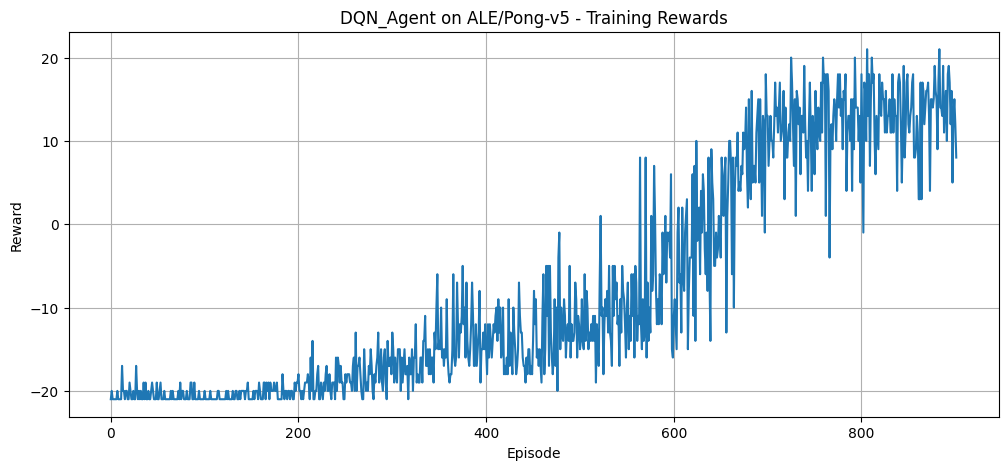

Saved loss plot to: ALE/Pong-v5\DQN_Agent\plots\DQN_Agent_ALE_Pong-v5_training_loss.png


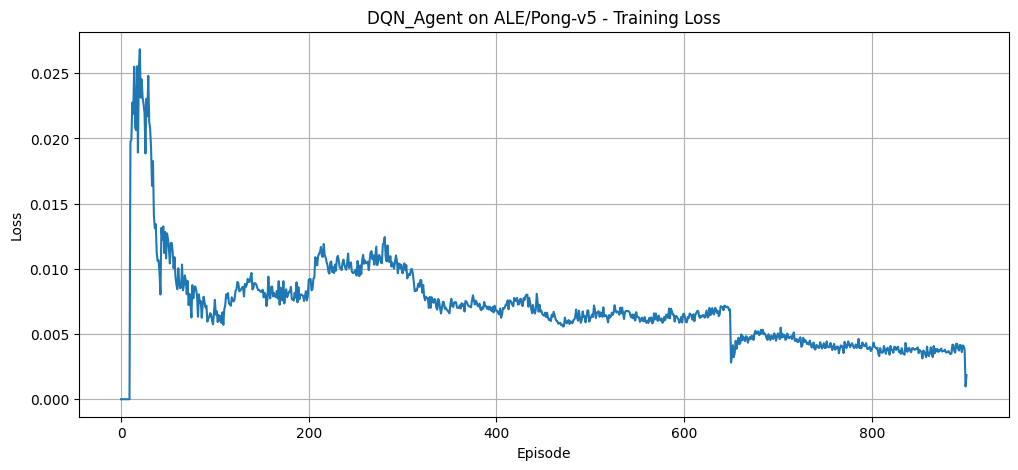


Generating evaluation GIFs...
Saved: ALE/Pong-v5\DQN_Agent\gifs\ALE_Pong-v5_rollout_1.gif
Saved: ALE/Pong-v5\DQN_Agent\gifs\ALE_Pong-v5_rollout_2.gif
Saved: ALE/Pong-v5\DQN_Agent\gifs\ALE_Pong-v5_rollout_3.gif
Saved: ALE/Pong-v5\DQN_Agent\gifs\ALE_Pong-v5_rollout_4.gif
Saved: ALE/Pong-v5\DQN_Agent\gifs\ALE_Pong-v5_rollout_5.gif
Saved combined GIF: ALE/Pong-v5\DQN_Agent\gifs\ALE_Pong-v5_combined.gif

✅ DQN_Agent on ALE/Pong-v5 complete. Saved to ALE/Pong-v5\DQN_Agent



In [37]:
# Train DQN Agent on Pong
rewards_dqn, losses_dqn = train_pong_agent(DQN_Agent, pong_config, 'ALE/Pong-v5', 15)


In [58]:
# Train DDQN Agent on Pong
rewards_ddqn, losses_ddqn = train_pong_agent(DDQNAgent, pong_config, 'ALE/Pong-v5', 15)


Using device: cuda
⚠️  torch.load raised an UnpicklingError (weights-only). Retrying with weights_only=False — only do this for trusted checkpoints.
✅ Loaded checkpoint: ALE/Pong-v5\DDQNAgent\checkpoints\checkpoint_epoch_450.pth (epoch 450)

Starting DDQNAgent on ALE/Pong-v5 from episode 450
Config: {'num_episodes': 2000, 'max_steps_per_episode': 18000, 'gamma': 0.99, 'learning_rate': 0.0001, 'target_update_freq': 10000, 'mem_size': 100000, 'epsilon_start': 1.0, 'epsilon_end': 0.01, 'epsilon_decay_steps': 200000, 'batch_size': 128, 'checkpoint_freq': 50, 'tau': 0.0001, 'learning_starts': 10000, 'train_freq': 4}
Epsilon will decay linearly from 1.0 to 0.01 over 200000 steps

  🎯 Hard update target network at step 910000
[ALE/Pong-v5][DDQNAgent] Episode 451/2000 | Reward: 2.0 | Avg100: -1.28 | Loss: 0.0023 | Epsilon: 0.010 | Steps: 3048 | TotalSteps: 912032
[ALE/Pong-v5][DDQNAgent] Episode 452/2000 | Reward: -4.0 | Avg100: -1.28 | Loss: 0.0022 | Epsilon: 0.010 | Steps: 3337 | TotalSteps:

KeyboardInterrupt: 

In [59]:
# 1. Winning games
base_dir = 'ALE/Pong-v5/DDQNAgent'
gifs_dir = os.path.join(base_dir, 'gifs')
checkpoint_dir = os.path.join(base_dir, 'checkpoints')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

agent = DDQNAgent(
    state_dim=None,
    action_dim=6,  # Pong has 6 actions
    gamma=pong_config['gamma'],
    lr=pong_config['learning_rate'],
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=1.0,
    buffer_capacity=pong_config['mem_size'],
    batch_size=pong_config['batch_size'],
    tau=pong_config['tau'],
    n_hidden=None,
    device=device,
    network_class=QNetwork_CNN
)
# Load the best checkpoint
ckpt = load_checkpoint_generic(checkpoint_dir, device=device)
if ckpt:
    if 'policy_net' in ckpt:
        agent.policy_net.load_state_dict(ckpt['policy_net'])
    print("Loaded checkpoint for GIF generation.")

create_pong_game_gifs(
    agent=agent,
    output_dir=os.path.join(gifs_dir, 'wins'),
    min_score=10,  # Games where we win by 10+ points
    num_games=5,
    max_attempts=50
)

⚠️  torch.load raised an UnpicklingError (weights-only). Retrying with weights_only=False — only do this for trusted checkpoints.
✅ Loaded checkpoint: ALE/Pong-v5/DDQNAgent\checkpoints\checkpoint_epoch_1100.pth (epoch 1100)
Loaded checkpoint for GIF generation.

🎬 Recording Pong games...
   Target: Games with score >= 10
   ✅ Saved game 1/5: WIN (score: 13.0, steps: 2355)
      ALE/Pong-v5/DDQNAgent\gifs\wins\game_1_WIN_score13.gif
   ✅ Saved game 2/5: WIN (score: 15.0, steps: 2331)
      ALE/Pong-v5/DDQNAgent\gifs\wins\game_2_WIN_score15.gif
   ✅ Saved game 3/5: WIN (score: 13.0, steps: 2611)
      ALE/Pong-v5/DDQNAgent\gifs\wins\game_3_WIN_score13.gif
   ✅ Saved game 4/5: WIN (score: 13.0, steps: 2589)
      ALE/Pong-v5/DDQNAgent\gifs\wins\game_4_WIN_score13.gif
   ⏭️ Attempt 5: Score 9 (not matching criteria)
   ✅ Saved game 5/5: WIN (score: 12.0, steps: 3195)
      ALE/Pong-v5/DDQNAgent\gifs\wins\game_5_WIN_score12.gif

✅ Successfully recorded 5 games!


5